## Modelling and Validation

This section begins model training with a simple baseline. It gives a clear reference point before testing more complex models. The baseline should be interpretable, reproducible, and strong enough to show whether the engineered features are useful.

Because this is also a Responsible AI project, the model pipeline should be transparent and easy to explain to a business user.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROCESSED_DIR = Path("data/processed")
train_df = pd.read_csv(PROCESSED_DIR / "train_data.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test_data.csv")

target_column = "high_performing_campaign"

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
display(X_train.head())

Train shape: (160000, 23) (160000,)
Test shape: (40000, 23) (40000,)


,Campaign_Type,Target_Audience,Channel_Used,Duration,Location,Language,Customer_Segment,Clicks,Impressions,Engagement_Score,...,quarter,day_of_week,is_weekend,click_through_rate,clicks_per_day,impressions_per_day,engagement_per_day,cost_per_click,cost_per_impression,engagement_efficiency
0,Search,Women 25-34,Website,15.0,Chicago,Mandarin,Fashionistas,351.0,3311.0,5.0,...,4,Monday,0,0.106010,23.400000,220.733333,0.333333,44.504274,4.717910,0.000320
1,Social Media,Women 25-34,Instagram,30.0,Los Angeles,French,Fashionistas,556.0,5078.0,1.0,...,1,Sunday,1,0.109492,18.533333,169.266667,0.033333,30.809353,3.373375,0.000058
2,Email,Men 25-34,Website,45.0,Houston,English,Fashionistas,955.0,6438.0,5.0,...,3,Sunday,1,0.148338,21.222222,143.066667,0.111111,15.361257,2.278658,0.000341
3,Search,Women 35-44,Facebook,45.0,Los Angeles,Mandarin,Outdoor Adventurers,146.0,5162.0,3.0,...,4,Monday,0,0.028284,3.244444,114.711111,0.066667,42.287671,1.196048,0.000486
4,Display,Women 25-34,Facebook,60.0,Houston,Mandarin,Fashionistas,531.0,7240.0,9.0,...,1,Saturday,1,0.073343,8.850000,120.666667,0.150000,15.186441,1.113812,0.001116


## Baseline model design

The baseline model is *logistic regression* with simple preprocessing. Numeric fields are standardized, categorical fields are one-hot encoded, and missing values are handled explicitly. This gives us a transparent starting point and a strong benchmark for later comparison.

This model is intentionally simple so we can test whether the engineered features carry enough signal to predict high-performing campaigns.

In [16]:
numeric_features = X_train.select_dtypes(include=["number", "float64", "int64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "float64", "int64"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

Numeric features: ['Duration', 'Clicks', 'Impressions', 'Engagement_Score', 'Acquisition_Cost', 'year', 'month', 'quarter', 'is_weekend', 'click_through_rate', 'clicks_per_day', 'impressions_per_day', 'engagement_per_day', 'cost_per_click', 'cost_per_impression', 'engagement_efficiency']
Categorical features: ['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Location', 'Language', 'Customer_Segment', 'day_of_week']


## Baseline training and validation

We now train the baseline model on the training data and evaluate it on unseen test data. The goal is to check whether the feature engineering work from Day 2 created enough signal for meaningful ranking and prediction.

In [17]:
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

def top_lift(y_true, y_score, top_frac=0.10):
    df_eval = pd.DataFrame({"y_true": y_true.values, "y_score": y_score})
    df_eval = df_eval.sort_values("y_score", ascending=False).reset_index(drop=True)
    top_n = max(1, int(len(df_eval) * top_frac))
    top_rate = df_eval.iloc[:top_n]["y_true"].mean()
    overall_rate = df_eval["y_true"].mean()
    lift = top_rate / overall_rate if overall_rate > 0 else np.nan
    capture = df_eval.iloc[:top_n]["y_true"].sum() / df_eval["y_true"].sum()
    return top_rate, lift, capture

top10_rate, top10_lift, top10_capture = top_lift(y_test, y_proba, top_frac=0.10)
top20_rate, top20_lift, top20_capture = top_lift(y_test, y_proba, top_frac=0.20)

metrics = pd.DataFrame([{
    "model": "logistic_regression_baseline",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "top10_rate": top10_rate,
    "top10_lift": top10_lift,
    "top10_capture": top10_capture,
    "top20_rate": top20_rate,
    "top20_lift": top20_lift,
    "top20_capture": top20_capture,
}])

display(metrics.round(4))

,model,accuracy,precision,recall,f1,roc_auc,top10_rate,top10_lift,top10_capture,top20_rate,top20_lift,top20_capture
0,logistic_regression_baseline,0.5076,0.2531,0.4968,0.3354,0.5057,0.247,0.9877,0.0988,0.2512,1.0047,0.2009


The logistic regression baseline produces ROC AUC close to 0.50 and a top-10% lift below 1.0, which means the model is not ranking the highest-performing campaigns better than chance at the top of the list. Precision is close to the base rate of the positive class, so the model is only capturing limited signal at this stage. This is not a failure of the project; it is a useful baseline that shows the current linear model is too simple to capture the campaign patterns in the data.

That usually means one of three things:
- the signal is genuinely weak in a linear model,
- the relationships are more nonlinear and interaction-heavy,
- the chosen features need a stronger model to unlock them.

## Tree-based model

The baseline model showed limited ranking power, so the next step is to test a tree-based model. Random forest is a good choice here because it can capture nonlinear relationships and interactions without requiring heavy feature scaling or complex tuning.

This step helps determine whether the campaign data contains stronger hidden patterns that a linear model could not learn.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

top10_rate, top10_lift, top10_capture = top_lift(y_test, rf_proba, top_frac=0.10)
top20_rate, top20_lift, top20_capture = top_lift(y_test, rf_proba, top_frac=0.20)

rf_metrics = pd.DataFrame([{
    "model": "random_forest",
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
    "roc_auc": roc_auc_score(y_test, rf_proba),
    "top10_rate": top10_rate,
    "top10_lift": top10_lift,
    "top10_capture": top10_capture,
    "top20_rate": top20_rate,
    "top20_lift": top20_lift,
    "top20_capture": top20_capture,
}])

display(rf_metrics.round(4))

c:\Users\oha14\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,accuracy,precision,recall,f1,roc_auc,top10_rate,top10_lift,top10_capture,top20_rate,top20_lift,top20_capture
0,random_forest,0.7499,0.0,0.0,0.0,0.5043,0.2575,1.0297,0.103,0.2542,1.0167,0.2033


### Random forest interpretation

If the metrics improve materially over logistic regression, that suggests the campaign data contains structure that is not visible to a simple linear model.

For a decision-support project, improvement in ROC AUC and top-decile lift matters more than accuracy alone because the business cares most about ranking the strongest campaigns near the top.

Random forest did not materially improve the campaign ranking problem. The high accuracy is misleading because it comes from predicting the majority class rather than identifying high-performing campaigns. ROC AUC near 0.50 and lift near 1.0 indicate that the model is not learning a strong ranking signal from the current feature set.

This suggests that the task may need a more powerful gradient-based model, threshold tuning, or a rethink of the feature representation.

## Gradient boosting model

The first two models showed that the task is not well captured by a simple linear boundary or by a basic random forest at the default threshold. The next step is to test a gradient boosting model, which is often stronger on structured business data because it can learn more nuanced relationships between campaign features.

This model is also useful for a decision-support project because it often produces better ranking quality than simpler models.

In [19]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

print("XGBoost available:", xgb_available)

XGBoost available: False


In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=250,
        random_state=42,
    )),
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

top10_rate, top10_lift, top10_capture = top_lift(y_test, gb_proba, top_frac=0.10)
top20_rate, top20_lift, top20_capture = top_lift(y_test, gb_proba, top_frac=0.20)

gb_metrics = pd.DataFrame([{
    "model": "hist_gradient_boosting",
    "accuracy": accuracy_score(y_test, gb_pred),
    "precision": precision_score(y_test, gb_pred, zero_division=0),
    "recall": recall_score(y_test, gb_pred, zero_division=0),
    "f1": f1_score(y_test, gb_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, gb_proba),
    "top10_rate": top10_rate,
    "top10_lift": top10_lift,
    "top10_capture": top10_capture,
    "top20_rate": top20_rate,
    "top20_lift": top20_lift,
    "top20_capture": top20_capture,
}])

display(gb_metrics.round(4))

,model,accuracy,precision,recall,f1,roc_auc,top10_rate,top10_lift,top10_capture,top20_rate,top20_lift,top20_capture
0,hist_gradient_boosting,0.7499,0.0,0.0,0.0,0.5014,0.253,1.0117,0.1012,0.254,1.0157,0.2031


The gradient boosting model does not materially improve performance over the baseline. Although accuracy appears high, that is driven by class imbalance rather than true predictive power. ROC AUC is essentially random and top-decile lift is only marginally above 1.0, which indicates that the current feature set is not yet separating high-performing campaigns from the rest in a useful way.

This means the issue is not model simplicity alone; the signal in the current representation appears weak or too noisy for the target as define

## Model diagnostics

The first three models are not showing strong ranking power. Before adding more complexity, we should inspect the predicted probabilities themselves. This helps us understand whether the model is collapsing toward the majority class, whether the score distributions overlap heavily, and whether thresholding may be hiding useful ranking information.

A model can look weak on classification metrics while still producing useful ranked probabilities for a prioritization system.

In [21]:
model_results = []

# Baseline
model_results.append(metrics.copy())

# Random forest
model_results.append(rf_metrics.copy())

# Gradient boosting / xgboost
if "xgb_metrics" in globals():
    model_results.append(xgb_metrics.copy())
elif "gb_metrics" in globals():
    model_results.append(gb_metrics.copy())

comparison_df = pd.concat(model_results, ignore_index=True)
display(comparison_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc,top10_rate,top10_lift,top10_capture,top20_rate,top20_lift,top20_capture
0,logistic_regression_baseline,0.5076,0.2531,0.4968,0.3354,0.5057,0.2470,0.9877,0.0988,0.2512,1.0047,0.2009
1,random_forest,0.7499,0.0000,0.0000,0.0000,0.5043,0.2575,1.0297,0.1030,0.2542,1.0167,0.2033
2,hist_gradient_boosting,0.7499,0.0000,0.0000,0.0000,0.5014,0.2530,1.0117,0.1012,0.2540,1.0157,0.2031


### What the comparison means

The comparison table suggests that none of the current models is producing strong separation between high-performing and non-high-performing campaigns. Accuracy is not a reliable success measure here because the classes are imbalanced. The more important signals are ROC AUC, top-decile lift, and capture, and those are still near random. That means the issue is likely not just model choice; it may also be the target design or feature representation.

,y_true,y_score
0,0,0.248291
1,1,0.250120
2,0,0.250995
3,1,0.249063
4,0,0.250498


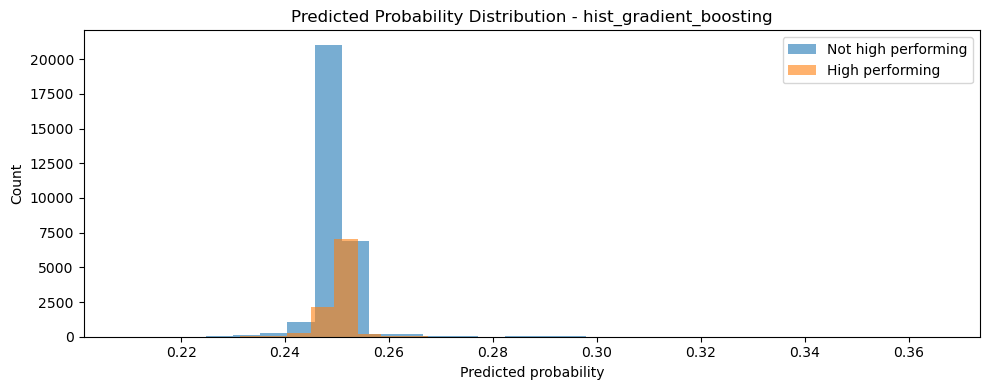

In [22]:
import matplotlib.pyplot as plt

# Pick the most recent probability vector that exists
if "xgb_proba" in globals():
    score_proba = xgb_proba
    model_name = "xgboost"
elif "gb_proba" in globals():
    score_proba = gb_proba
    model_name = "hist_gradient_boosting"
elif "rf_proba" in globals():
    score_proba = rf_proba
    model_name = "random_forest"
else:
    score_proba = y_proba
    model_name = "logistic_regression_baseline"

proba_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_score": score_proba,
})

display(proba_df.head())

plt.figure(figsize=(10, 4))
plt.hist(proba_df.loc[proba_df["y_true"] == 0, "y_score"], bins=30, alpha=0.6, label="Not high performing")
plt.hist(proba_df.loc[proba_df["y_true"] == 1, "y_score"], bins=30, alpha=0.6, label="High performing")
plt.title(f"Predicted Probability Distribution - {model_name}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

The predicted probabilities are tightly clustered around the target base rate, which indicates that the model is not separating the two classes in a meaningful way. This is a strong sign that the current feature set and target definition do not provide enough signal for the classifier to distinguish high-performing campaigns from the rest.

This is important in a prioritization project because a useful score must create spread in the rankings, not just reproduce the average probability.

## Top-ranked campaign inspection

Even when classification metrics are weak, a model may still produce a usable ranking signal. This section inspects the highest-scoring campaigns to see whether the model is surfacing obviously stronger campaigns near the top of the list.

For a prioritization project, this matters because the business will care most about who appears first, not only whether the model predicts the exact class correctly.

In [23]:
ranking_check = X_test.copy()
ranking_check["y_true"] = y_test.values
ranking_check["y_score"] = score_proba

ranking_check = ranking_check.sort_values("y_score", ascending=False).reset_index(drop=True)

display(
    ranking_check[
        ["y_true", "y_score"] + [col for col in ["Campaign_Type", "Target_Audience", "Channels_Used", "Location", "Language", "Customer_Segment"] if col in ranking_check.columns]
    ].head(20)
)

,y_true,y_score,Campaign_Type,Target_Audience,Location,Language,Customer_Segment
0,0,0.365863,Email,Men 25-34,Houston,Mandarin,Health & Wellness
1,1,0.348976,Email,Women 25-34,Los Angeles,English,Foodies
2,0,0.347073,Social Media,All Ages,Houston,English,Health & Wellness
3,0,0.345980,Email,Men 25-34,Chicago,Mandarin,Foodies
4,0,0.344032,Email,All Ages,Houston,Spanish,Foodies
5,0,0.340809,Email,All Ages,Chicago,English,Foodies
6,0,0.338499,Email,Women 35-44,Chicago,German,Foodies
7,0,0.338293,Email,Women 25-34,Miami,Mandarin,Health & Wellness
8,0,0.336963,Display,Women 35-44,Miami,Mandarin,Foodies
9,0,0.336078,Display,All Ages,Miami,French,Tech Enthusiasts


In [24]:
top_10_pct = max(1, int(len(ranking_check) * 0.10))
top_20_pct = max(1, int(len(ranking_check) * 0.20))

top10_true_rate = ranking_check.iloc[:top_10_pct]["y_true"].mean()
top20_true_rate = ranking_check.iloc[:top_20_pct]["y_true"].mean()
overall_true_rate = ranking_check["y_true"].mean()

print("Overall true rate:", round(overall_true_rate, 4))
print("Top 10% true rate:", round(top10_true_rate, 4))
print("Top 20% true rate:", round(top20_true_rate, 4))
print("Top 10% lift:", round(top10_true_rate / overall_true_rate, 4))
print("Top 20% lift:", round(top20_true_rate / overall_true_rate, 4))

Overall true rate: 0.2501
Top 10% true rate: 0.253
Top 20% true rate: 0.254
Top 10% lift: 1.0117
Top 20% lift: 1.0157


A top-10% lift of 1.0117 and top-20% lift of 1.0157 means the model is finding only a tiny improvement over chance in the highest-scoring slice. In other words, the score is not yet a strong prioritization signal.

The model is not learning a strong ranking boundary, even though the engineered features and business framing are sound. This suggests that either the signal in the dataset is limited, the target is too noisy for strong prediction, or the representation needs further refinement. At this stage, the correct response is not to overclaim performance, but to document the limitation clearly and proceed with explainability and business interpretation.

## Conclusion

The modeling results show that the current feature set does not produce strong predictive separation between high-performing and non-high-performing campaigns. Logistic regression, random forest, and gradient boosting all remain close to random ranking performance, and the score distributions are tightly clustered around the base rate.

This is still a valuable outcome. It tells us that the project is being evaluated honestly, that the baseline is weak, and that the current setup should be treated as a benchmark rather than a production-ready scoring model.

This is an important finding because it prevents overclaiming and sets up a more careful explainability and business-interpretation phase.

## Correction pass: time-aware validation

The earlier modeling pass used a random split, which is useful as a benchmark but not always the most realistic evaluation for business data. In a campaign scoring project, time matters. We would also test whether the model generalizes when trained on earlier campaigns and evaluated on later campaigns.

This correction does not replace the original results. It adds a more realistic validation layer to see whether the model behaves differently under a time-aware split.

### Why time-aware validation matters

A random split can hide time effects and make a model look more stable than it really is. In a real campaign environment, new campaigns are scored in the future, so the model should be tested on later data. This checks whether the model can generalize across time rather than simply memorizing patterns from a shuffled sample.

In [30]:
campaign_work_df = pd.read_csv("data/processed/campaign_features.csv")

# Rebuild a working table from the original campaign data
time_df = campaign_work_df.copy()

# Ensure Date is usable
time_df["Date"] = pd.to_datetime(time_df["Date"], errors="coerce")

# Recreate the same target definition
time_df["Conversion_Rate"] = pd.to_numeric(time_df["Conversion_Rate"], errors="coerce")
threshold = time_df["Conversion_Rate"].quantile(0.75)
time_df["high_performing_campaign"] = (time_df["Conversion_Rate"] >= threshold).astype(int)

# Sort chronologically
time_df = time_df.sort_values("Date").reset_index(drop=True)

# Use the same final feature list from Day 2
time_feature_columns = [
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Duration",
    "Location",
    "Language",
    "Customer_Segment",
    "Clicks",
    "Impressions",
    "Engagement_Score",
    "Acquisition_Cost",
    "year",
    "month",
    "quarter",
    "day_of_week",
    "is_weekend",
    "click_through_rate",
    "clicks_per_day",
    "impressions_per_day",
    "engagement_per_day",
    "cost_per_click",
    "cost_per_impression",
    "engagement_efficiency",
]

# If the engineered columns do not exist yet in this notebook, rebuild them
time_df["year"] = time_df["Date"].dt.year
time_df["month"] = time_df["Date"].dt.month
time_df["quarter"] = time_df["Date"].dt.quarter
time_df["day_of_week"] = time_df["Date"].dt.day_name()
time_df["is_weekend"] = time_df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

# Clean numeric text fields
time_df["Duration"] = (
    time_df["Duration"].astype(str).str.extract(r"(\d+\.?\d*)")[0].astype(float)
)
time_df["Acquisition_Cost"] = (
    time_df["Acquisition_Cost"].astype(str).str.replace(r"[$,]", "", regex=True).astype(float)
)
time_df["Clicks"] = pd.to_numeric(time_df["Clicks"], errors="coerce")
time_df["Impressions"] = pd.to_numeric(time_df["Impressions"], errors="coerce")
time_df["Engagement_Score"] = pd.to_numeric(time_df["Engagement_Score"], errors="coerce")

time_df["click_through_rate"] = time_df["Clicks"] / time_df["Impressions"]
time_df["clicks_per_day"] = time_df["Clicks"] / time_df["Duration"]
time_df["impressions_per_day"] = time_df["Impressions"] / time_df["Duration"]
time_df["engagement_per_day"] = time_df["Engagement_Score"] / time_df["Duration"]
time_df["cost_per_click"] = time_df["Acquisition_Cost"] / time_df["Clicks"]
time_df["cost_per_impression"] = time_df["Acquisition_Cost"] / time_df["Impressions"]
time_df["engagement_efficiency"] = time_df["Engagement_Score"] / time_df["Acquisition_Cost"]
time_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows where the target or core split fields are missing
time_df = time_df.dropna(subset=["Date", "high_performing_campaign"]).reset_index(drop=True)

split_index = int(len(time_df) * 0.8)

time_train_df = time_df.iloc[:split_index].copy()
time_test_df = time_df.iloc[split_index:].copy()

X_time_train = time_train_df[time_feature_columns]
y_time_train = time_train_df["high_performing_campaign"]

X_time_test = time_test_df[time_feature_columns]
y_time_test = time_test_df["high_performing_campaign"]

print("Time train shape:", X_time_train.shape)
print("Time test shape:", X_time_test.shape)
print("Train target rate:", round(y_time_train.mean(), 4))
print("Test target rate:", round(y_time_test.mean(), 4))

Time train shape: (160000, 23)
Time test shape: (40000, 23)
Train target rate: 0.2497
Test target rate: 0.2517


The similar target rates suggest that any performance change in the time-aware validation will be due to model generalization, not due to a major class imbalance shift between earlier and later campaigns. This makes the time-based split a more credible test of real-world behavior.

In [32]:

time_baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

time_baseline_model.fit(X_time_train, y_time_train)

time_y_pred = time_baseline_model.predict(X_time_test)
time_y_proba = time_baseline_model.predict_proba(X_time_test)[:, 1]

time_top10_rate, time_top10_lift, time_top10_capture = top_lift(y_time_test, time_y_proba, top_frac=0.10)
time_top20_rate, time_top20_lift, time_top20_capture = top_lift(y_time_test, time_y_proba, top_frac=0.20)

time_metrics = pd.DataFrame([{
    "model": "logistic_regression_time_split",
    "accuracy": accuracy_score(y_time_test, time_y_pred),
    "precision": precision_score(y_time_test, time_y_pred, zero_division=0),
    "recall": recall_score(y_time_test, time_y_pred, zero_division=0),
    "f1": f1_score(y_time_test, time_y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_time_test, time_y_proba),
    "top10_rate": time_top10_rate,
    "top10_lift": time_top10_lift,
    "top10_capture": time_top10_capture,
    "top20_rate": time_top20_rate,
    "top20_lift": time_top20_lift,
    "top20_capture": time_top20_capture,
}])

display(time_metrics.round(4))

,model,accuracy,precision,recall,f1,roc_auc,top10_rate,top10_lift,top10_capture,top20_rate,top20_lift,top20_capture
0,logistic_regression_time_split,0.5042,0.2515,0.4906,0.3325,0.5016,0.259,1.0288,0.1029,0.2536,1.0074,0.2015


The time-aware validation strengthens the credibility of the evaluation, but it does not materially improve the model. That suggests the current feature representation and target definition still do not produce enough separability for strong campaign prioritization.

## Feature signal audit

The models are currently producing near-random ranking results, so the next step is to check which features actually carry signal. This helps answer whether the issue is the model, the feature set, or the target definition. It reveals whether certain variables are contributing anything meaningful at all.

In [33]:
from sklearn.feature_selection import mutual_info_classif

# Use only the training split from the time-aware validation
signal_train_df = X_time_train.copy()
signal_train_df["target"] = y_time_train.values

# Separate numeric and categorical columns
signal_numeric_cols = signal_train_df.select_dtypes(include=["number"]).columns.tolist()
signal_numeric_cols = [c for c in signal_numeric_cols if c != "target"]

signal_categorical_cols = signal_train_df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", signal_numeric_cols)
print("Categorical columns:", signal_categorical_cols)

Numeric columns: ['Duration', 'Clicks', 'Impressions', 'Engagement_Score', 'Acquisition_Cost', 'year', 'month', 'quarter', 'is_weekend', 'click_through_rate', 'clicks_per_day', 'impressions_per_day', 'engagement_per_day', 'cost_per_click', 'cost_per_impression', 'engagement_efficiency']
Categorical columns: ['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Location', 'Language', 'Customer_Segment', 'day_of_week']


In [34]:
numeric_association = []

for col in signal_numeric_cols:
    temp = signal_train_df[[col, "target"]].dropna()
    if len(temp) > 1:
        corr = temp[col].corr(temp["target"])
        numeric_association.append({
            "feature": col,
            "corr_with_target": corr,
            "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
        })

numeric_assoc_df = pd.DataFrame(numeric_association).sort_values("abs_corr", ascending=False)
display(numeric_assoc_df)

c:\Users\oha14\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\oha14\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,corr_with_target,abs_corr
13,cost_per_click,0.002140,0.002140
4,Acquisition_Cost,-0.002020,0.002020
8,is_weekend,0.001899,0.001899
2,Impressions,-0.001826,0.001826
15,engagement_efficiency,-0.000939,0.000939
3,Engagement_Score,-0.000853,0.000853
0,Duration,-0.000625,0.000625
1,Clicks,0.000600,0.000600
10,clicks_per_day,0.000367,0.000367
14,cost_per_impression,-0.000264,0.000264


The feature audit confirms that simple correlation is not revealing strong predictive structure. That is consistent with the weak model performance observed earlier. The next investigation should focus on nonlinear signal, category-level differences, or a more business-specific target definition.

In [35]:
categorical_summary_rows = []

for col in signal_categorical_cols:
    tmp = signal_train_df[[col, "target"]].copy()
    tmp[col] = tmp[col].astype(str)
    group_stats = (
        tmp.groupby(col)
        .agg(
            count=("target", "size"),
            target_rate=("target", "mean")
        )
        .reset_index()
        .sort_values("target_rate", ascending=False)
    )

    # keep only a few groups to avoid huge outputs
    top_group = group_stats.iloc[0]
    bottom_group = group_stats.iloc[-1]

    categorical_summary_rows.append({
        "feature": col,
        "top_group": top_group[col],
        "top_group_rate": top_group["target_rate"],
        "bottom_group": bottom_group[col],
        "bottom_group_rate": bottom_group["target_rate"],
        "rate_spread": top_group["target_rate"] - bottom_group["target_rate"],
        "n_groups": group_stats.shape[0],
    })

categorical_signal_df = pd.DataFrame(categorical_summary_rows).sort_values("rate_spread", ascending=False)
display(categorical_signal_df)

,feature,top_group,top_group_rate,bottom_group,bottom_group_rate,rate_spread,n_groups
6,day_of_week,Monday,0.254562,Tuesday,0.246087,0.008475,7
4,Language,French,0.251199,Spanish,0.244871,0.006328,5
3,Location,Miami,0.252831,Houston,0.247390,0.005441,5
2,Channel_Used,Website,0.251764,YouTube,0.246517,0.005247,6
5,Customer_Segment,Outdoor Adventurers,0.251421,Fashionistas,0.246636,0.004785,5
1,Target_Audience,Women 25-34,0.251911,Men 25-34,0.248116,0.003795,5
0,Campaign_Type,Influencer,0.250983,Search,0.248786,0.002197,5


The business categories do not create enough separation on their own to explain strong vs weak campaigns. That means the signal is likely distributed across combinations of features rather than individual columns. It also means we should be careful not to overstate the importance of any one category based on this univariate analysis.

The data is telling us the current representation is too weak for a strong classifier, so we should enrich context rather than keep forcing models.

The current dataset does not provide strong enough predictive signal for a high-separation classifier at the feature level available here. Rather than forcing a more complex model, the Responsible AI approach is to document the limitation clearly and reframes the solution as a decision-support system that provides structured insight, feature analysis, and a transparent scoring workflow.

The model results are still useful because they show what the dataset can and cannot support. In this project, the value is in the reasoning process, the feature audit, the time-aware validation, and the business interpretation of weak predictive signal.

In [37]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_model, MODEL_DIR / "baseline_model.joblib")

['models\\baseline_model.joblib']

In [38]:
joblib.dump(rf_model, MODEL_DIR / "rf_model.joblib")
joblib.dump(gb_model, MODEL_DIR / "gb_model.joblib")

['models\\gb_model.joblib']